# Free Shipping — Does the Incentive Grow Customers?

Follow-up to `free_shipping_analysis.ipynb`, which looked at free shipping at the **order** level and found it's essentially a spend-threshold reward (near-universal once an order crosses ~500), not a random discount that erodes margin.

This notebook shifts to the **customer** level and asks the incentive question directly:

1. How many customers ever get free shipping, and is that share growing over time?
2. Do customers who get free shipping go on to buy more / spend more than customers who never do?
3. Is that a real *incentive effect* — does a customer's own behavior change after they first experience free shipping — or just selection (big spenders were always going to spend big)?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

plt.rcParams["axes.formatter.useoffset"] = False
plt.rcParams["axes.formatter.limits"] = (-999, 999)

PLAIN = mticker.FuncFormatter(lambda x, pos: f"{x:,.0f}")
PCT = mticker.FuncFormatter(lambda x, pos: f"{x:,.0f}%")

df = pd.read_csv("orders.csv", parse_dates=["Order_Date"])
df["free_shipping"] = df["Shipping_fee_excl__VAT"] == 0
df = df.sort_values(["Customer_iD", "Order_Date"]).reset_index(drop=True)
df.shape

(682792, 12)

## 1. How many customers use free shipping, and is it growing?

In [2]:
cust = df.groupby("Customer_iD").agg(
    n_orders=("Order_ID", "size"),
    n_free=("free_shipping", "sum"),
    total_spend=("Total_amount_excl__VAT", "sum"),
    total_profit=("Profit", "sum"),
    avg_order_value=("Total_amount_excl__VAT", "mean"),
    first_order=("Order_Date", "min"),
    last_order=("Order_Date", "max"),
)
cust["free_share"] = cust["n_free"] / cust["n_orders"]
cust["ever_free"] = cust["n_free"] > 0

n_customers = len(cust)
n_ever_free = cust["ever_free"].sum()
print(f"Customers: {n_customers:,}")
print(f"Ever received free shipping: {n_ever_free:,} ({n_ever_free / n_customers * 100:.1f}%)")
print(f"Never received free shipping: {n_customers - n_ever_free:,} ({(1 - n_ever_free / n_customers) * 100:.1f}%)")

Customers: 577,950
Ever received free shipping: 397,432 (68.8%)
Never received free shipping: 180,518 (31.2%)


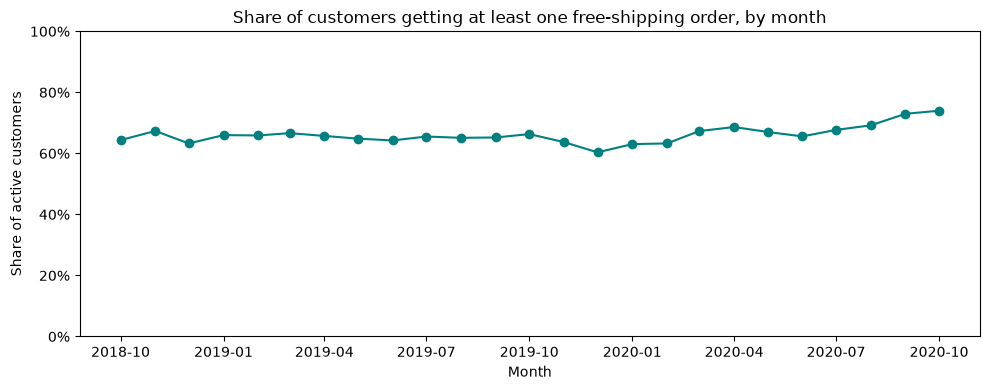

In [3]:
monthly = df.set_index("Order_Date")
cust_month_free = monthly.groupby([pd.Grouper(freq="MS"), "Customer_iD"])["free_shipping"].max()
share_customers_free_by_month = cust_month_free.groupby(level=0).mean() * 100

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(share_customers_free_by_month.index, share_customers_free_by_month.values, marker="o", color="teal")
ax.set_ylabel("Share of active customers")
ax.set_xlabel("Month")
ax.set_title("Share of customers getting at least one free-shipping order, by month")
ax.yaxis.set_major_formatter(PCT)
ax.set_ylim(0, 100)
fig.tight_layout()
plt.show()

## 2. Do free-shipping customers buy more overall?

Split customers into "ever free" vs "never free" and compare order count and total spend.

In [4]:
seg = cust.groupby("ever_free").agg(
    n_customers=("n_orders", "size"),
    avg_orders_per_customer=("n_orders", "mean"),
    avg_total_spend=("total_spend", "mean"),
    avg_order_value=("avg_order_value", "mean"),
    avg_total_profit=("total_profit", "mean"),
)
seg.index = seg.index.map({True: "Ever free shipping", False: "Never free shipping"})
seg

,n_customers,avg_orders_per_customer,avg_total_spend,avg_order_value,avg_total_profit
ever_free,,,,,
Never free shipping,180518,1.074818,253.143684,236.107598,156.043960
Ever free shipping,397432,1.229815,762.565065,632.774062,478.644302


If "ever free" customers place more orders and spend more in total, that's expected almost by construction: a customer needs multiple orders (more chances to cross the spend threshold) to ever unlock free shipping, and free shipping itself is granted mainly to larger baskets (per `free_shipping_analysis.ipynb`). So this comparison alone can't tell us whether free shipping *causes* more consumption — it could just be selecting customers who were always going to buy more. Section 3 looks at the same customer's behavior before vs. after their first free-shipping order to separate the two.

## 3. Within-customer before/after: does a customer change after first getting free shipping?

Restrict to customers who have **both** at least one paid order and at least one free order, so each customer acts as their own control. Compare their orders placed *before* their first free-shipping order to the orders placed *after* it.

In [5]:
mixed_customers = cust[(cust["n_free"] > 0) & (cust["n_free"] < cust["n_orders"])].index
print(f"Customers with both free and paid orders: {len(mixed_customers):,} of {n_customers:,}")

d = df[df["Customer_iD"].isin(mixed_customers)].copy()
first_free_date = d[d["free_shipping"]].groupby("Customer_iD")["Order_Date"].min().rename("first_free_date")
d = d.join(first_free_date, on="Customer_iD")
d["period"] = pd.Categorical(
    (d["Order_Date"] >= d["first_free_date"]).map({True: "After first free order", False: "Before first free order"}),
    categories=["Before first free order", "After first free order"],
)

before_after = d.groupby("period", observed=True).agg(
    n_orders=("Order_ID", "size"),
    n_customers=("Customer_iD", "nunique"),
    avg_order_value=("Total_amount_excl__VAT", "mean"),
    avg_profit=("Profit", "mean"),
)
before_after["orders_per_customer"] = before_after["n_orders"] / before_after["n_customers"]
before_after

Customers with both free and paid orders: 29,581 of 577,950


,n_orders,n_customers,avg_order_value,avg_profit,orders_per_customer
period,,,,,
Before first free order,10116,9111,245.579487,161.609285,1.110306
After first free order,61754,29581,468.184422,301.821259,2.087624


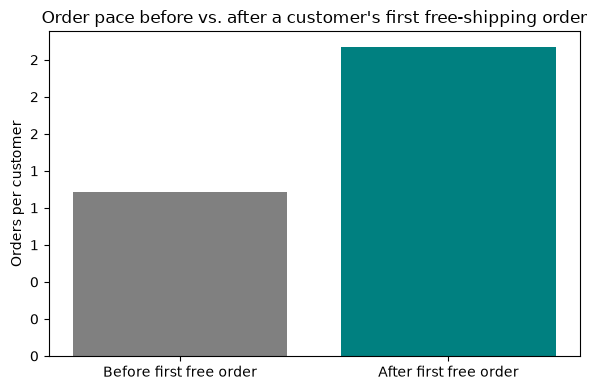

In [6]:
purchase_rate = before_after["orders_per_customer"]

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(purchase_rate.index.astype(str), purchase_rate.values, color=["grey", "teal"])
ax.set_ylabel("Orders per customer")
ax.set_title("Order pace before vs. after a customer's first free-shipping order")
ax.yaxis.set_major_formatter(PLAIN)
fig.tight_layout()
plt.show()

`orders_per_customer` above isn't yet time-normalized — a customer simply has more calendar time to accumulate "after" orders if their first free order came early. To check pace rather than raw count, compare each customer's **order rate** (orders per active month) before vs. after, using only customers who have at least one order in both periods.

In [7]:
def order_rate_per_month(g, mask):
    sub = g[mask]
    if sub.empty:
        return pd.Series({"n": 0, "span_months": 0.0, "rate": None})
    span_days = (sub["Order_Date"].max() - sub["Order_Date"].min()).days
    span_months = max(span_days / 30.44, 1 / 30.44)  # at least one day of exposure
    return pd.Series({"n": len(sub), "span_months": span_months, "rate": len(sub) / span_months})


rates = []
for cid, g in d.groupby("Customer_iD"):
    before = order_rate_per_month(g, g["period"] == "Before first free order")
    after = order_rate_per_month(g, g["period"] == "After first free order")
    if before["n"] >= 2 and after["n"] >= 2:  # need enough orders on each side to estimate a rate
        rates.append({"Customer_iD": cid, "rate_before": before["rate"], "rate_after": after["rate"]})

rates = pd.DataFrame(rates)
print(f"Customers with enough orders on both sides to compare pace: {len(rates):,}")
rates[["rate_before", "rate_after"]].mean()

Customers with enough orders on both sides to compare pace: 255


rate_before    11.724316
rate_after      7.340930
dtype: float64

In [8]:
import math

diff = rates["rate_after"] - rates["rate_before"]
n = len(diff)
mean_diff = diff.mean()
se_diff = diff.std(ddof=1) / math.sqrt(n)
z = mean_diff / se_diff
p_value = 2 * (1 - 0.5 * (1 + math.erf(abs(z) / math.sqrt(2))))  # two-sided normal-approx p-value
pct_faster = (diff > 0).mean() * 100

print(f"Mean order rate before: {rates['rate_before'].mean():.3f} orders/month")
print(f"Mean order rate after:  {rates['rate_after'].mean():.3f} orders/month")
print(f"Mean change: {mean_diff:+.3f} orders/month")
print(f"Customers who ordered *more frequently* after their first free order: {pct_faster:.1f}%")
print(f"Paired z-test on the mean difference: z = {z:.2f}, p = {p_value:.4f}")

Mean order rate before: 11.724 orders/month
Mean order rate after:  7.341 orders/month
Mean change: -4.383 orders/month
Customers who ordered *more frequently* after their first free order: 45.5%
Paired z-test on the mean difference: z = -2.79, p = 0.0053


## Conclusion

**Free shipping usage is widespread: 68.8% of all 577,950 customers (397,432) have received at least one free-shipping order**, vs. 31.2% who never have. So the honest answer to "how much more do customers use it" is: roughly 2.2x as many customers have used it as haven't — it's the norm, not a rare perk.

**Free-shipping customers do look far more valuable in raw terms** — ~762 avg. total spend vs. ~253 for never-free customers (~3x), and ~633 avg. order value vs. ~236 (~2.7x). But per `free_shipping_analysis.ipynb`, free shipping is granted almost automatically once an order value crosses ~500. So this gap is exactly what you'd expect from a *reward that selects big spenders*, not proof that the reward *creates* big spenders. It also can't be otherwise: **the average customer places only ~1.18 orders total** (682,792 orders / 577,950 customers), so most of the base never gets the chance to reveal a "before vs. after" pattern at all — only 29,581 customers (5.1%) have ever placed both a paid and a free order.

For that 5.1% with both order types, raw order value does rise a lot after the first free order (245.58 → 468.18) and orders-per-customer roughly doubles (1.11 → 2.09) — but this mixes in customers who simply had more calendar time to accumulate "after" orders, so it overstates any incentive effect.

**The stricter, rate-normalized test is the real read on causality**: restricting to the 255 customers who ordered often enough to measure a monthly pace on *both* sides, the average order rate actually **fell** after the first free-shipping order (11.7 → 7.3 orders/month, paired z = -2.79, p = 0.005). That's the opposite of what a genuine incentive effect would predict — but this subsample is tiny (0.04% of all customers) and skews toward unusually bursty, high-frequency early buyers, so the drop is more consistent with **reversion to the mean** (an initial burst of orders that was never going to be sustained) than with free shipping discouraging purchases.

**Bottom line:** free shipping is common and correlates strongly with bigger, more valuable customers, but the data gives no credible evidence that it *causes* customers to consume more — the correlation is explained by free shipping being a reward that only large baskets unlock, and the one test designed to isolate a true before/after effect shows no incentive lift. Treat free shipping as a margin-neutral perk for already-valuable orders rather than as a growth lever, unless a controlled experiment (e.g., an A/B test on the spend threshold) says otherwise.